# **Imports**

In [1]:
!pip install pmdarima
!pip install git+https://github.com/scikit-learn-contrib/py-earth@v0.2dev

     |████████████████████████████████| 1.5 MB 5.2 MB/s 
     |████████████████████████████████| 9.5 MB 56.0 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2
  Cloning https://github.com/scikit-learn-contrib/py-earth (to revision v0.2dev) to /tmp/pip-req-build-pq86zok0
  Running command git clone -q https://github.com/scikit-learn-contrib/py-earth /tmp/pip-req-build-pq86zok0
  Running command git checkout -b v0.2dev --track origin/v0.2dev
  Switched to a new branch 'v0.2dev'
  Branch 'v0.2dev' set up to track remote branch 'v0.2dev' from 'origin'.
  Created wheel for sklearn-contrib-py-earth: filename=sklearn_contrib_py_earth-0.1.0+16.g400f84d-cp37-cp37m-linux_x86_64.whl size=3997343 sha256=73b8c1791ce40fa32ef6c0a3f1b3af00f9dbbc30bcf2d98f048e128909c64963
  Stored in directory: /tmp/pip-ephem-wheel-cache-_gmfxp1y/wheels/79/d7/aa/1e418a9aea84424ef2ce2697ae7c

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import datetime
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import sklearn
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots  import plot_acf as pltacf
from  statsmodels.tsa.stattools import pacf as PACF
from statsmodels.graphics.tsaplots  import plot_pacf as pltpacf
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [3]:
!gdown --id 123BKpZ3L_KXuCqnHno9x10lIfRcHJfol

Downloading...
From: https://drive.google.com/uc?id=123BKpZ3L_KXuCqnHno9x10lIfRcHJfol
To: /content/JSWSTEEL.NS.csv
100% 165k/165k [00:00<00:00, 60.3MB/s]


In [4]:
stock_name="JSWSTEEL"

In [5]:
df_stock = pd.read_csv('JSWSTEEL.NS.csv',index_col='Date')
df_stock.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,102.889999,103.680000,102.050003,102.699997,4507190.0,4,1,1,7791.299805,1.629997
2016-01-04,102.300003,106.099998,101.830002,104.470001,12127750.0,0,4,1,7784.649902,4.269997
2016-01-05,105.610001,109.135002,105.224998,108.309998,14205180.0,1,5,1,7741.000000,3.910004
2016-01-06,108.300003,109.699997,105.199997,105.820000,8015450.0,2,6,1,7568.299805,4.500000
2016-01-07,103.525002,104.599998,102.254997,102.635002,5304630.0,3,7,1,7601.350098,2.345001


#**ARIMA - Autoregression Intergrated Moving Average**

##*Decomposing the data*

In [6]:
df_stock['Close'].head()

Date
2016-01-01    102.699997
2016-01-04    104.470001
2016-01-05    108.309998
2016-01-06    105.820000
2016-01-07    102.635002
Name: Close, dtype: float64

Text(0.5, 1.0, 'Close Price - JSWSTEEL')

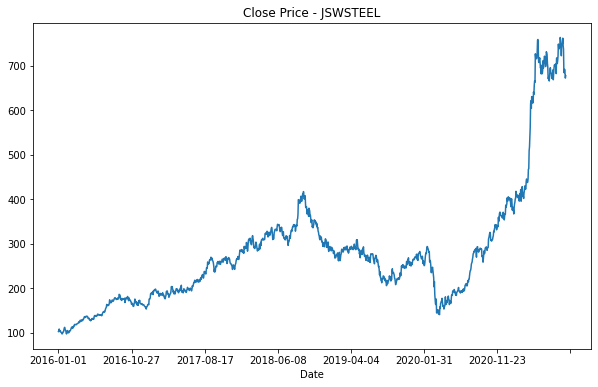

In [7]:
plt.rcParams['figure.figsize'] = (10,6)
df_stock['Close'].plot()
plt.title("Close Price - "+stock_name)

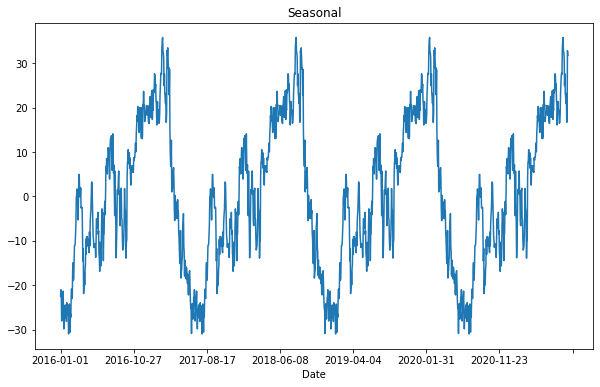

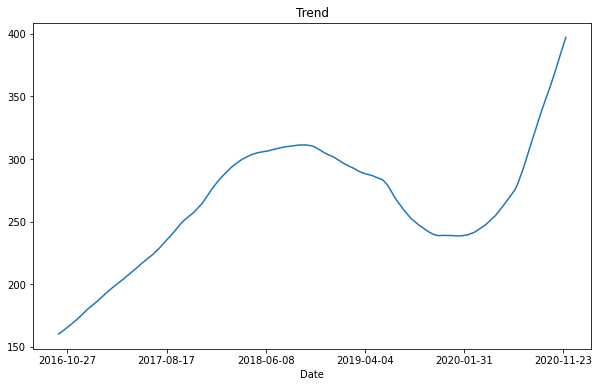

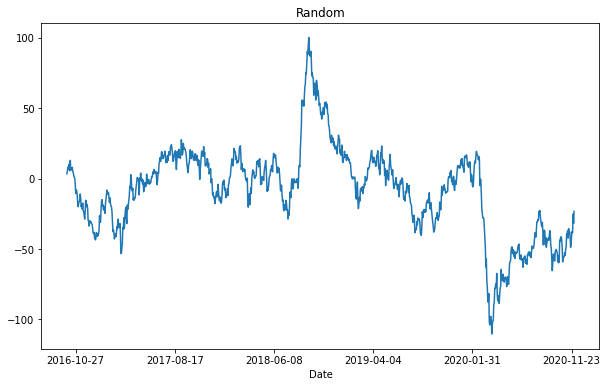

In [8]:
plt.rcParams['figure.figsize'] = (10,6)
decomposition=seasonal_decompose(df_stock['Close'],freq=365)
decomposition.seasonal.plot()
plt.title("Seasonal")
plt.show()
decomposition.trend.plot()
plt.title("Trend")
plt.show()
decomposition.resid.plot()
plt.title("Random")
plt.show()

##*Stationary Check*

In [9]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Close'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  print(dftest[1])
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print(dfoutput)
print("Differencing Value : ",dvalue)

0.8775132046486905
2.4208860546398475e-08
Test Statistic                -6.365092e+00
p-value                        2.420886e-08
#lags used                     1.800000e+01
number of observations used    1.368000e+03
critical value (1%)           -3.435139e+00
critical value (5%)           -2.863655e+00
critical value (10%)          -2.567896e+00
dtype: float64
Differencing Value :  2


##*ACF*

In [10]:
from  statsmodels.tsa.stattools import acf as ACF
ACFOutput = ACF(Stationary_df.dropna(),nlags=20)
print(ACFOutput)

[ 1.         -0.03648642  0.037457    0.00701994  0.06973796  0.07358517
 -0.02220874  0.09571852 -0.06378636 -0.03008982  0.07570042  0.04325921
  0.07699072  0.0021189   0.02417904  0.02876658 -0.04584571  0.11495017
 -0.03279692  0.0675602  -0.02670174]


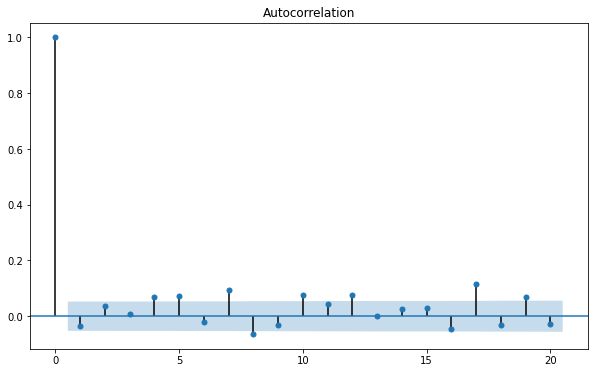

In [11]:
plt.rcParams['figure.figsize'] = (10,6)
pltacf(Stationary_df.dropna(),lags=20)
plt.show()

##*PACF*

In [12]:
PACFOutput = PACF(Stationary_df.dropna(),nlags=20)
print(PACFOutput)

[ 1.         -0.03651274  0.0362262   0.00970354  0.06936221  0.07881488
 -0.02173576  0.08910947 -0.06313596 -0.05244923  0.07562197  0.04297962
  0.07388953  0.02448262  0.00332213  0.02190155 -0.05972123  0.08487537
 -0.02368361  0.05748334 -0.01050927]


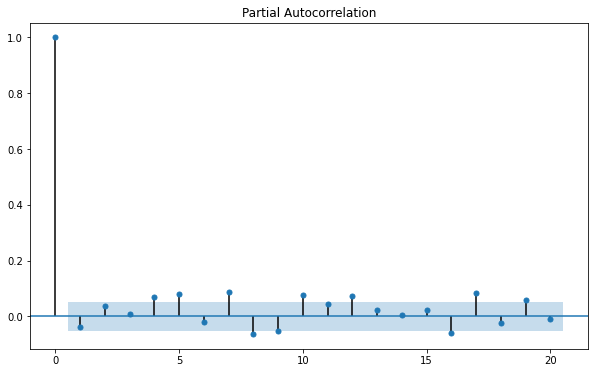

In [13]:
plt.rcParams['figure.figsize'] = (10,6)
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

##*Test and Train Split*

In [14]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Close']
df_stock_test=df_stock.loc['2021-07-31':]['Close']

In [15]:
df_stock_train.tail()

Date
2021-07-26    704.549988
2021-07-27    710.650024
2021-07-28    721.700012
2021-07-29    748.400024
2021-07-30    736.950012
Name: Close, dtype: float64

In [16]:
df_stock_test.head()

Date
2021-08-02    746.700012
2021-08-03    740.299988
2021-08-04    747.250000
2021-08-05    763.250000
2021-08-06    757.349976
Name: Close, dtype: float64

##*Model Fitting*

In [17]:
arima_model=auto_arima(df_stock_train,seasonal=False,max_p=2,max_d=2,max_q=2,start_p=0,start_q=0,d=1)

In [18]:
arima_model

ARIMA(maxiter=50, method='lbfgs', order=(0, 1, 0), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=True)

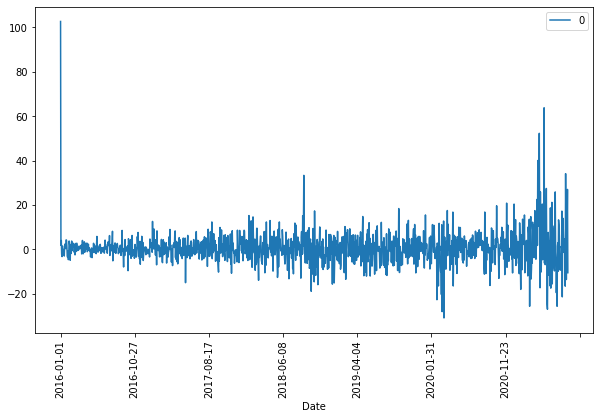

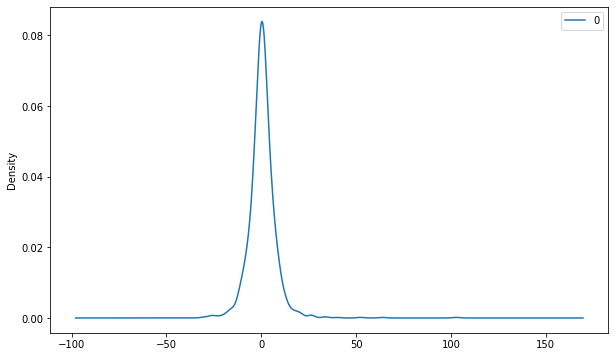

                 0
count  1369.000000
mean      0.550241
std       7.386055
min     -31.009078
25%      -2.737858
50%       0.384364
75%       3.495388
max     102.699997


In [19]:
model = ARIMA(df_stock_train, order=(1,1,1))
model_fit = model.fit()
residuals = pd.DataFrame(model_fit.resid)
plt.rcParams['figure.figsize'] = (10,6)
residuals.plot()
plt.xticks(rotation=90)
plt.show()
residuals.plot(kind='kde')
plt.show()
print(residuals.describe())

##*Forecasting and Testing*

In [20]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values)):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)
error = np.sqrt(mean_squared_error(df_stock_test.values, predictions))
print('Test Error Percentage',(error/np.mean(df_stock_test.values))*100)

Test Error Percentage 2.3437840249640045


([], <a list of 0 Text major ticklabel objects>)

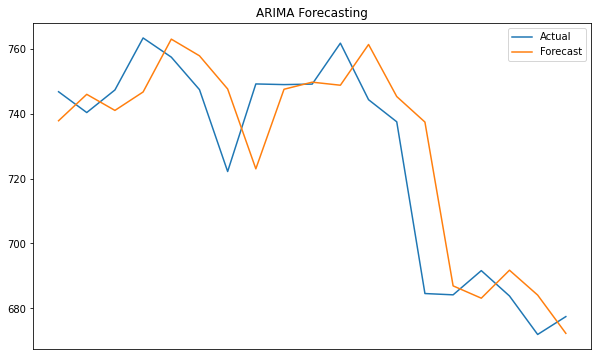

In [21]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(df_stock_test, label='Actual')
plt.plot(predictions, label='Forecast')
plt.title('ARIMA Forecasting')
plt.legend()
plt.xticks([])

##*Forecast for August*

In [22]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [23]:
predictions

[737.7735523853557,
 745.9028542050676,
 740.9557418847496,
 746.6297240955827,
 762.891492212769,
 757.7580270185349,
 747.5506053569767,
 722.9779983153667,
 747.4641501861653,
 749.6460646754913,
 748.7048405282284,
 761.2430067468589,
 745.2236768325843,
 737.3661281242873]

#**MARS - Multivariate Adaptive Regression Splines**

In [24]:
from pyearth import Earth

In [25]:
df_stock_mars_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:5].copy()
df_stock_mars_test=df_stock.loc['2021-07-31':].iloc[:,:5].copy()

In [26]:
df_stock_mars_train.shape

(1369, 5)

In [27]:
df_stock_mars_test.shape

(19, 5)

In [28]:
df_stock_mars_train.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-01,102.889999,103.680000,102.050003,102.699997,4507190.0
2016-01-04,102.300003,106.099998,101.830002,104.470001,12127750.0
2016-01-05,105.610001,109.135002,105.224998,108.309998,14205180.0
2016-01-06,108.300003,109.699997,105.199997,105.820000,8015450.0
2016-01-07,103.525002,104.599998,102.254997,102.635002,5304630.0


In [29]:
df_stock_mars_test

,Open,High,Low,Close,Volume
Date,,,,,
2021-08-02,741.400024,751.450012,733.500000,746.700012,6971560.0
2021-08-03,746.000000,746.000000,728.400024,740.299988,6939253.0
2021-08-04,741.000000,754.000000,736.400024,747.250000,6680733.0
2021-08-05,747.250000,765.400024,740.500000,763.250000,8613347.0
2021-08-06,767.500000,776.500000,755.700012,757.349976,8973665.0
2021-08-09,761.849976,762.500000,742.450012,747.349976,5119564.0
2021-08-10,748.900024,750.000000,719.599976,722.150024,6382357.0
2021-08-11,727.000000,752.000000,727.000000,749.099976,11909486.0
2021-08-12,753.049988,754.299988,741.400024,748.900024,3506281.0


In [30]:
x_train_mars = df_stock_mars_train.drop(['Close'], axis=1)
y_train_mars = df_stock_mars_train['Close']
x_test_mars = df_stock_mars_test.drop(['Close'], axis=1)
y_test_mars = df_stock_mars_test['Close']

##*Fitting the model*

In [31]:
MARS_model = Earth(max_terms = 600,max_degree=3)
MARS_model_fitted = MARS_model.fit(x_train_mars, y_train_mars)
y_pred_mars = MARS_model_fitted.predict(x_test_mars[:14])

##*Evaluating the model*

In [32]:
MSE = mean_squared_error(y_test_mars[:14], y_pred_mars)
RMSE = np.sqrt(MSE)
RMSE_mean = (RMSE/np.mean(y_test_mars[:14]))*100
print("RMSE Score :", round(RMSE, 2))
print("RMSE/Mean", round(RMSE_mean,1))

RMSE Score : 11.14
RMSE/Mean 1.5


##*Plotting Forecast vs Actual* 

([], <a list of 0 Text major ticklabel objects>)

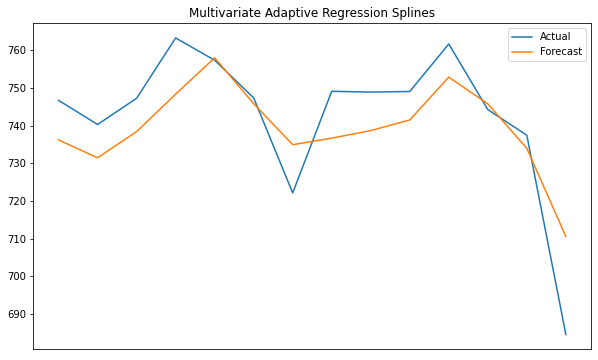

In [33]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(y_test_mars[:14], label='Actual')
plt.plot(y_pred_mars, label='Forecast')
plt.title('Multivariate Adaptive Regression Splines')
plt.legend()
plt.xticks([])

#**VAR - Vector Autoregression**

In [34]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [35]:
df_stock_var = df_stock.loc['2016-01-01':'2021-08-20'].iloc[:,:4].copy()
df_stock_var_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:4].copy()
df_stock_var_test=df_stock.loc['2021-07-31':'2021-08-20'].iloc[:,:4].copy()


In [36]:
df_stock_var_train.shape

(1369, 4)

In [37]:
df_stock_var_test.shape

(14, 4)

In [38]:
df_stock_var.shape

(1383, 4)

##*Plotting the Data*

In [39]:
fig, axes = plt.subplots(nrows=4, ncols=1, dpi=120, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df_stock_var[df_stock_var.columns[i]]
    ax.plot(data, linewidth=1)
    # Decorations
    ax.set_title(df_stock_var.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout()

##*Granger Causality Test*

In [40]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df_stock_var, variables = df_stock_var.columns)        

,Open_x,High_x,Low_x,Close_x
Open_y,1.0,0.0,0.0000,0.0
High_y,0.0,1.0,0.0000,0.0
Low_y,0.0,0.0,1.0000,0.0
Close_y,0.0,0.0,0.0005,1.0


##*Cointegration Test*

In [41]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df_stock_var, alpha=0.05): 
    out = coint_johansen(df_stock_var,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    print('Name   ::  Test Statistic > C(95%)    =>   Significance  \n', '--'*20)
    for col, trace, cvt in zip(df_stock_var.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df_stock_var)

Name   ::  Test Statistic > C(95%)    =>   Significance  
 ----------------------------------------
Open   ::  556.6     > 40.1749   =>   True
High   ::  302.59    > 24.2761   =>   True
Low    ::  90.91     > 12.3212   =>   True
Close  ::  3.57      > 4.1296    =>   False


##*ADF Test*

In [42]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")    

In [43]:
# ADF Test on each column
for name, column in df_stock_var_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 0.8863
 No. Lags Chosen       = 12
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.9929. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 0.7221
 No. Lags Chosen       = 22
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.9903. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit roo

##*ADF Test on first order differencing*

In [44]:
df_differenced = df_stock_var_train.diff().dropna()

In [45]:
# ADF Test on each column of 1st Differences Dataframe
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -5.9912
 No. Lags Chosen       = 18
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -6.322
 No. Lags Chosen       = 21
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05


##*Selecting the number of lags*

In [46]:
model = VAR(df_differenced)
x = model.select_order(maxlags=20)
x.summary()

,AIC,BIC,FPE,HQIC
0,12.66,12.68,3.153e+05,12.67
1,10.89,10.97,5.367e+04,10.92
2,10.35,10.49,3.122e+04,10.40
3,10.10,10.30,2.424e+04,10.17
4,9.963,10.23,2.123e+04,10.06
5,9.848,10.17*,1.892e+04,9.970
6,9.813,10.20,1.827e+04,9.958
7,9.743,10.19,1.703e+04,9.910
8,9.713,10.22,1.654e+04,9.904
9,9.671,10.24,1.585e+04,9.885


##*Fitting the model*

In [47]:
model_fitted = model.fit(x.aic)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Sep, 2021
Time:                     16:44:57
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    10.7430
Nobs:                     1348.00    HQIC:                   9.96032
Log likelihood:          -13724.3    FPE:                    13256.2
AIC:                      9.49164    Det(Omega_mle):         10496.7
--------------------------------------------------------------------
Results for equation Open
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.059771         0.077290            0.773           0.439
L1.Open          -0.979200         0.038243          -25.605           0.000
L1.High           0.028866         0.034084            0.847           0.397


##*Durbin Watson Test*

In [48]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

for col, val in zip(df_stock_var.columns, out):
    print(col, ':', round(val, 2))

Open : 2.01
High : 2.0
Low : 2.01
Close : 2.0


##*Getting the Forecast*

In [49]:
# Get the lag order
lag_order = model_fitted.k_ar
print(lag_order)

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

20


array([[ -6.75      ,  -7.04998779, -12.09997559,  -9.25      ],
       [ -8.04998779,  -7.95001221,  -3.04998779,   1.45001221],
       [ -0.25      ,   6.70001221,   5.        ,   0.40002441],
       [ -0.95001221,  12.29998779,  -0.45001221,  17.25      ],
       [ 16.20001221,  -2.54998779,  -2.34997559, -22.15002441],
       [-17.        ,  -7.85003662,   3.34997559,  13.29998779],
       [ 14.        ,  20.15002441,  10.84997559,  12.90002441],
       [ 13.        ,  -0.25      ,  13.15002441,   6.95001221],
       [  6.        ,   2.34997559,   0.20001221,  -1.        ],
       [ -4.        ,   2.10003662,   1.84997559,  -1.30004883],
       [  3.5       ,  -0.95001221,   4.65002441,   4.5       ],
       [ -6.5       ,   5.34997559,  -6.70001221,  -5.19995117],
       [  0.65002441, -14.34997559, -18.59997559, -16.40002441],
       [ -7.75      ,  24.59997559,  13.64996338,  34.54998779],
       [ 37.        ,   4.40002441,  22.95001221,   1.        ],
       [  2.59997559,   2

In [50]:
nobs = 14
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df_stock_var.index[-nobs:], columns=df_stock_var.columns + '_1d')
df_forecast

,Open_1d,High_1d,Low_1d,Close_1d
Date,,,,
2021-08-02,-7.946940,-9.348474,-5.073272,-0.847930
2021-08-03,-5.353323,-4.673282,-6.812531,-3.087618
2021-08-04,9.128381,6.010346,9.420254,5.084430
2021-08-05,0.368245,4.242669,1.975977,7.951773
2021-08-06,3.748059,4.509991,6.132895,2.770099
2021-08-09,6.463536,4.193921,2.513785,1.068997
2021-08-10,-2.911501,-1.458482,-3.750704,-1.237819
2021-08-11,2.225874,-3.140996,-2.664989,-8.601629
2021-08-12,-7.551605,2.181962,-0.273452,12.096384


##*Inverting forecast back to original scale*

In [51]:
def invert_transformation(df_train, df_forecast, first_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        if first_diff:
          # Roll back 1st Diff
          df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [52]:
df_results = invert_transformation(df_stock_var_train, df_forecast, first_diff=True)        
df_results.loc[:, ['Open_forecast','High_forecast','Low_forecast','Close_forecast']]

,Open_forecast,High_forecast,Low_forecast,Close_forecast
Date,,,,
2021-08-02,738.203085,748.501502,728.476716,736.102082
2021-08-03,732.849762,743.828219,721.664186,733.014464
2021-08-04,741.978143,749.838566,731.084440,738.098893
2021-08-05,742.346388,754.081234,733.060417,746.050666
2021-08-06,746.094447,758.591225,739.193312,748.820765
2021-08-09,752.557983,762.785146,741.707096,749.889762
2021-08-10,749.646481,761.326664,737.956392,748.651943
2021-08-11,751.872355,758.185667,735.291403,740.050314
2021-08-12,744.320751,760.367629,735.017951,752.146698


##*Plotting Forecast vs Actual*

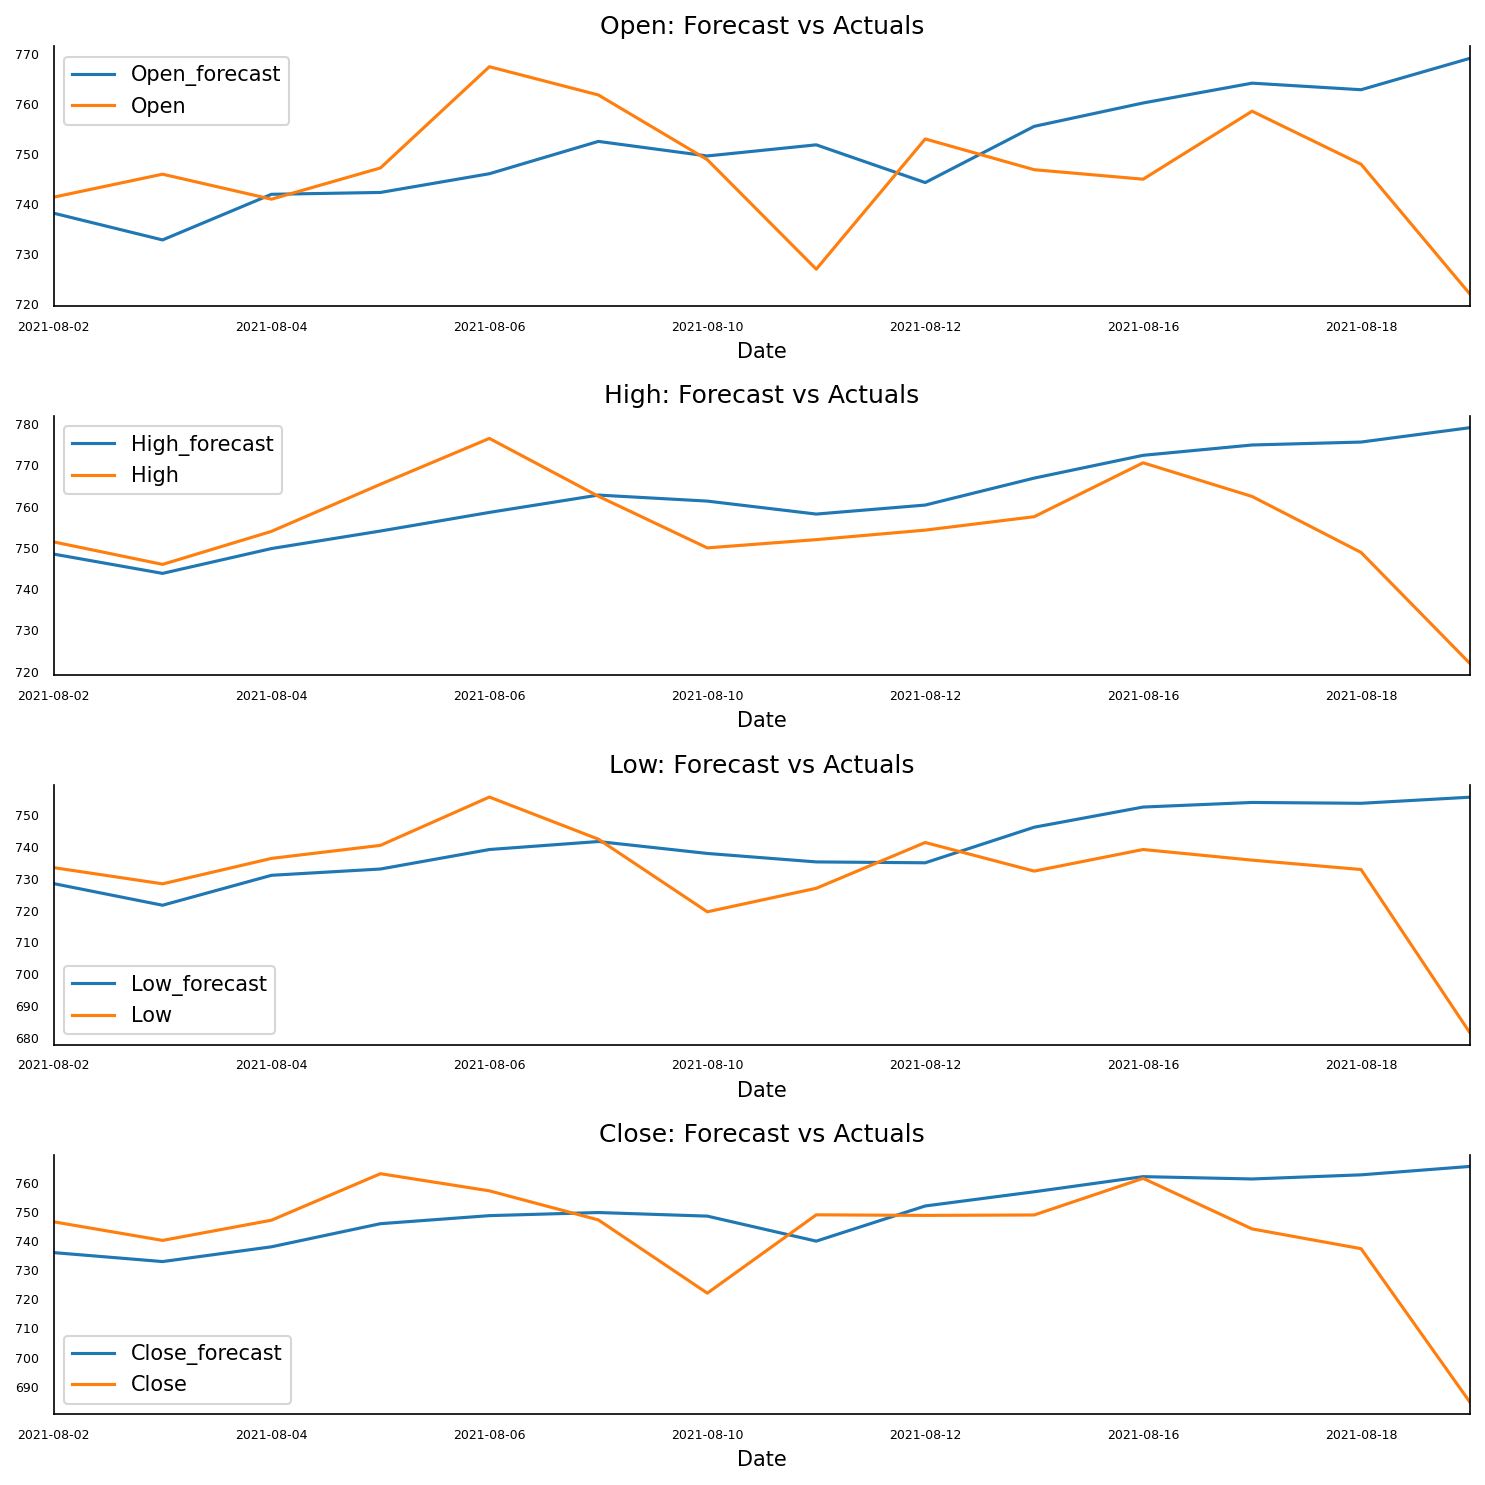

In [53]:
 fig, axes = plt.subplots(nrows=4, ncols=1, dpi=150, figsize=(10,10))
 for i, (col,ax) in enumerate(zip(df_stock_var.columns, axes.flatten())):
   df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
   df_stock_var_test[col][-nobs:].plot(legend=True, ax=ax);
   ax.set_title(col + ": Forecast vs Actuals")
   ax.xaxis.set_ticks_position('none')
   ax.yaxis.set_ticks_position('none')
   ax.spines["top"].set_alpha(0)
   ax.tick_params(labelsize=6)

plt.tight_layout();

##*Evaluating the model*

In [54]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual): 
    rmse = np.mean((forecast - actual)**2)**.5  
    rmse_p = (rmse/np.mean(actual))*100
    return({'rmse':rmse,'rmse_mean':rmse_p})

print('Forecast Accuracy of Open')
accuracy_prod = forecast_accuracy(df_results['Open_forecast'].values, df_stock_var_test['Open'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of High')
accuracy_prod = forecast_accuracy(df_results['High_forecast'].values, df_stock_var_test['High'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Low')
accuracy_prod = forecast_accuracy(df_results['Low_forecast'].values, df_stock_var_test['Low'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Close')
accuracy_prod = forecast_accuracy(df_results['Close_forecast'].values, df_stock_var_test['Close'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))



Forecast Accuracy of Open
rmse :  17.3936
rmse_mean :  2.3293

Forecast Accuracy of High
rmse :  18.7157
rmse_mean :  2.478

Forecast Accuracy of Low
rmse :  23.1523
rmse_mean :  3.1633

Forecast Accuracy of Close
rmse :  25.3684
rmse_mean :  3.4152


#**Linear Regression**

In [55]:
df_stock_train_lin=df_stock.loc['2016-01-01':'2021-07-31'].copy()
df_stock_test_lin=df_stock.loc['2021-07-31':].copy()


##*Normalize the data*

In [56]:
from sklearn.preprocessing import MinMaxScaler

In [57]:
scaler = MinMaxScaler()
df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.fit_transform(df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])
df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [58]:
df_stock_train_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,0.008279,0.003988,0.010665,102.699997,0.058734,4,1,1,0.091661,0.001213
2016-01-04,0.007397,0.007589,0.010332,104.470001,0.165002,0,4,1,0.090919,0.036788
2016-01-05,0.012348,0.012106,0.015468,108.309998,0.193971,1,5,1,0.086044,0.031937
2016-01-06,0.016371,0.012946,0.015430,105.820000,0.107656,2,6,1,0.066755,0.039887
2016-01-07,0.009229,0.005357,0.010975,102.635002,0.069854,3,7,1,0.070447,0.010848


In [59]:
df_stock_test_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,0.963353,0.967932,0.965888,746.700012,0.093099,0,2,8,1.023069,0.221129
2021-08-03,0.970234,0.959821,0.958173,740.299988,0.092648,1,3,8,1.037370,0.216413
2021-08-04,0.962755,0.971726,0.970275,747.250000,0.089043,2,4,8,1.041369,0.216413
2021-08-05,0.972104,0.988691,0.976477,763.250000,0.115993,3,5,8,1.035070,0.314783
2021-08-06,1.002393,1.005208,0.999471,757.349976,0.121018,4,6,8,1.037309,0.259534


##*Checking for multicollinearity*

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor    

def calculate_vif_(X, thresh=10,verbose=True):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
        

        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            if verbose == True:
                print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True
    if verbose == True:
        print('Remaining variables:')
        print(X.columns[variables])
    return X[cols[variables]]

##*Model Generation*

In [61]:
def forward_regression(X, y,
                       threshold_in,
                       verbose=False):
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        if not changed:
            break

    return included

In [62]:
def backward_regression(X, y,
                           threshold_out,
                           verbose=False):
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [63]:
def model_generator(df_train,df_test):
    train_dummy=pd.get_dummies(df_train,columns=['Day of Week','Day of Month','Month'])
    test_dummy = pd.get_dummies(df_test,columns=['Day of Week','Day of Month','Month'])
    for i in [1,2,3,4,5,6,7,9,10,11,12]:
        test_dummy['Month_'+str(i)] = 0
        test_dummy['Month_'+str(i)] = test_dummy['Month_'+str(i)].astype('uint8')
    for i in range(1,32):
      if (i not in df_test['Day of Month'].unique()):
        test_dummy['Day of Month_'+str(i)] = 0
        test_dummy['Day of Month_'+str(i)] = test_dummy['Day of Month_'+str(i)].astype('uint8')   
    X=train_dummy.drop('Close',axis=1)
    y=train_dummy["Close"]
    X_f=calculate_vif_(X.select_dtypes(exclude='uint8'),10,False)
    X_f=pd.concat([X_f,X.iloc[:,6:]],axis=1)
    model=sm.OLS(y,X_f[backward_regression(X_f,y,0.01)],axis=1).fit()
    pred=model.predict(test_dummy[backward_regression(X_f,y,0.01)])
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(test_dummy['Close'], pred))
    rmse_pct= (rmse/np.mean(test_dummy['Close']))*100
    sig_var = model.pvalues.index.tolist()
    return model,sig_var,rmse_pct    

In [64]:
 model,variables,rmse_per = model_generator(df_stock_train_lin,df_stock_test_lin)

In [65]:
print(model.summary2())

                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.811     
Dependent Variable: Close            AIC:                14908.6147
Date:               2021-09-15 16:45 BIC:                14966.0549
No. Observations:   1369             Log-Likelihood:     -7443.3   
Df Model:           10               F-statistic:        588.5     
Df Residuals:       1358             Prob (F-statistic): 0.00      
R-squared:          0.813            Scale:              3115.9    
-------------------------------------------------------------------
                Coef.   Std.Err.    t    P>|t|    [0.025    0.975] 
-------------------------------------------------------------------
Volume        -186.8230  26.9139 -6.9415 0.0000 -239.6203 -134.0256
NIFTY50        411.8219   8.4956 48.4749 0.0000  395.1560  428.4878
Range          422.1331  26.5627 15.8919 0.0000  370.0247  474.2415
Day of Week_0   68.0600   4.7162 14.4310 0.0000   58.8081   77.311

In [66]:
print("Significance Variables :",'\n',*variables,sep='\n')

Significance Variables :


Volume
NIFTY50
Range
Day of Week_0
Day of Week_1
Day of Week_2
Day of Week_3
Day of Week_4
Month_4
Month_5
Month_6


In [67]:
print("RMSE Percentage",rmse_per,sep='\n')

RMSE Percentage
18.291984936502445
